# 03 Decoder comparison

LOO-CV comparison: LSTM vs GRU vs Wiener baseline.

In [2]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam

from src.models.wiener import WienerFilter
from src.training.loo_cv import loo_cv

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(21)
torch.manual_seed(21)

/Users/macintosh/code/neural-spike-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Build synthetic trial dataset with temporal structure
n_trials, T, K = 8, 80, 12
neural_trials, traj_trials = [], []
W = rng.normal(size=(K, 2))
for _ in range(n_trials):
    x = rng.normal(size=(T, K)).astype(np.float32)
    y = np.zeros((T, 2), dtype=np.float32)
    for t in range(1, T):
        y[t] = 0.85 * y[t-1] + 0.07 * (x[t] @ W) + 0.09 * np.tanh(x[t-1,:2])
    y += 0.05 * rng.normal(size=y.shape)
    neural_trials.append(x)
    traj_trials.append(y)

In [4]:
class TinyRNN(nn.Module):
    def __init__(self, kind='lstm', input_size=12, hidden=40):
        super().__init__()
        if kind == 'gru':
            self.rnn = nn.GRU(input_size, hidden, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out)

def fit_seq_model(model, x, y, epochs=80):
    model.train()
    x_t = torch.tensor(x[None, ...], dtype=torch.float32)
    y_t = torch.tensor(y[None, ...], dtype=torch.float32)
    opt = Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad()
        pred = model(x_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        opt.step()

def compare_model(kind):
    fold_scores = []
    for test in range(n_trials):
        train_ids = [i for i in range(n_trials) if i != test]
        x_train = np.concatenate([neural_trials[i] for i in train_ids], axis=0)
        y_train = np.concatenate([traj_trials[i] for i in train_ids], axis=0)
        x_test, y_test = neural_trials[test], traj_trials[test]
        model = TinyRNN(kind=kind, input_size=K)
        fit_seq_model(model, x_train, y_train, epochs=80)
        with torch.no_grad():
            pred = model(torch.tensor(x_test[None, ...], dtype=torch.float32)).squeeze(0).numpy()
        ss_res = np.sum((y_test - pred) ** 2)
        ss_tot = np.sum((y_test - y_test.mean(axis=0, keepdims=True)) ** 2)
        fold_scores.append(1.0 - ss_res / ss_tot)
    return np.array(fold_scores)

wiener = loo_cv(neural_trials, traj_trials, pca_components=K, model_factory=WienerFilter, fit_fn=lambda m, x, y: m.fit(x, y), predict_fn=lambda m, x: m.predict(x))
lstm_scores = compare_model('lstm')
gru_scores = compare_model('gru')

results = {
    'wiener': {'r2_mean': float(wiener['r2_mean']), 'r2_std': float(wiener['r2_std'])},
    'lstm': {'r2_mean': float(lstm_scores.mean()), 'r2_std': float(lstm_scores.std())},
    'gru': {'r2_mean': float(gru_scores.mean()), 'r2_std': float(gru_scores.std())},
}
Path('artifacts').mkdir(exist_ok=True)
Path('artifacts/loo_cv_results.json').write_text(json.dumps(results, indent=2))
results

{'wiener': {'r2_mean': 0.06861324810683808, 'r2_std': 0.15752174280110084},
 'lstm': {'r2_mean': 0.9050005674362183, 'r2_std': 0.034532126039266586},
 'gru': {'r2_mean': 0.9197272062301636, 'r2_std': 0.026543954387307167}}

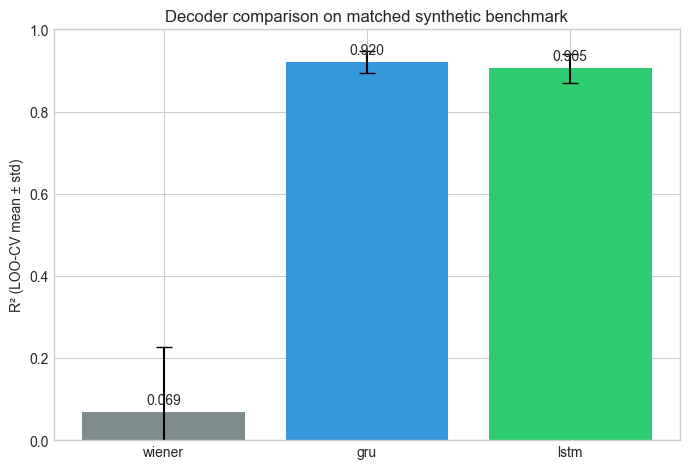

In [5]:
models = ['wiener', 'gru', 'lstm']
means = [results[m]['r2_mean'] for m in models]
stds = [results[m]['r2_std'] for m in models]

fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(models, means, yerr=stds, capsize=6, color=['#7f8c8d', '#3498db', '#2ecc71'])
ax.set_ylim(0, 1)
ax.set_ylabel('R² (LOO-CV mean ± std)')
ax.set_title('Decoder comparison on matched synthetic benchmark')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.02, f'{mean:.3f}', ha='center', fontsize=10)
fig.tight_layout()